XGBoost version : 1.7.6
SHAP version : 0.49.1
Patching: C:\Users\User\anaconda3\envs\credit_override_env\lib\site-packages\shap\explainers\_tree.py
Patch already applied – no change needed.
SHAP values shape : (43405, 68)
Expected value    : 0.1634


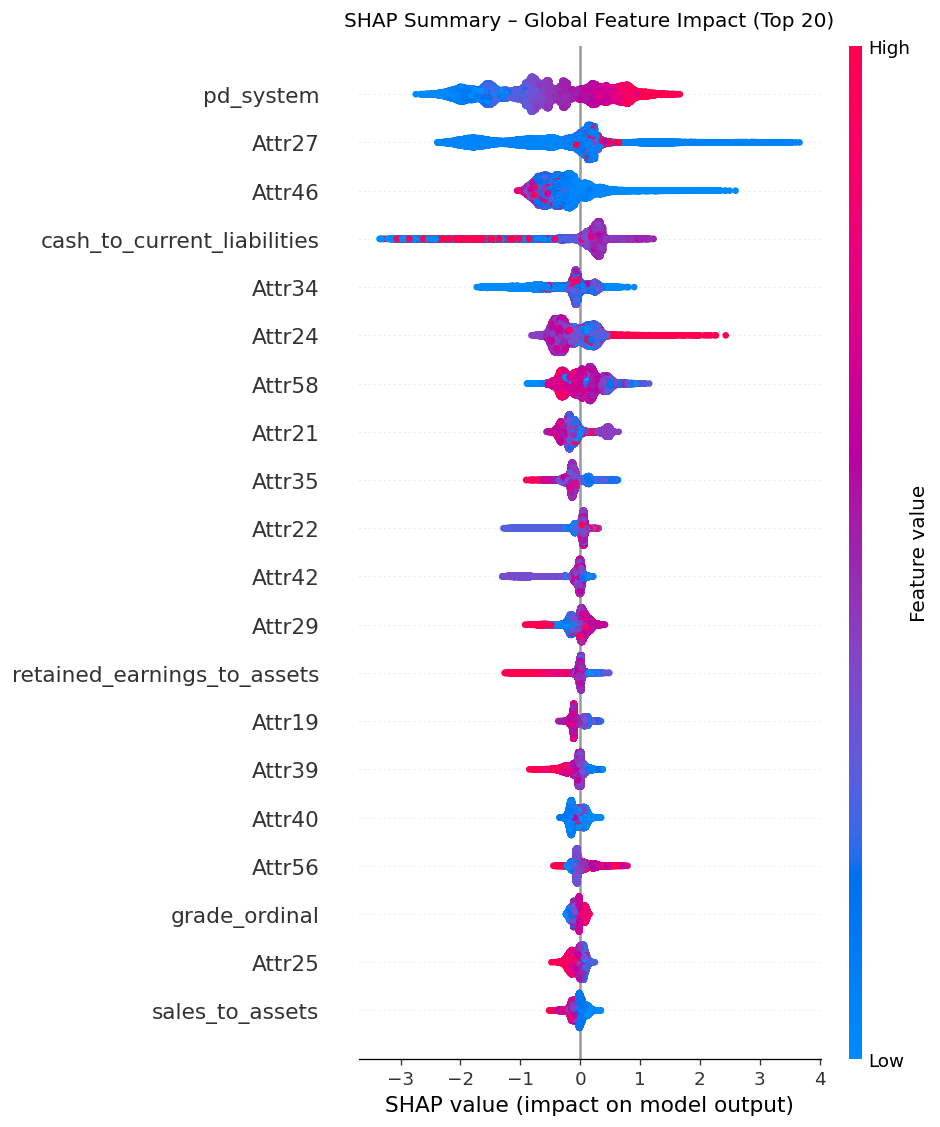

Figure saved: 12_shap_summary_beeswarm.png


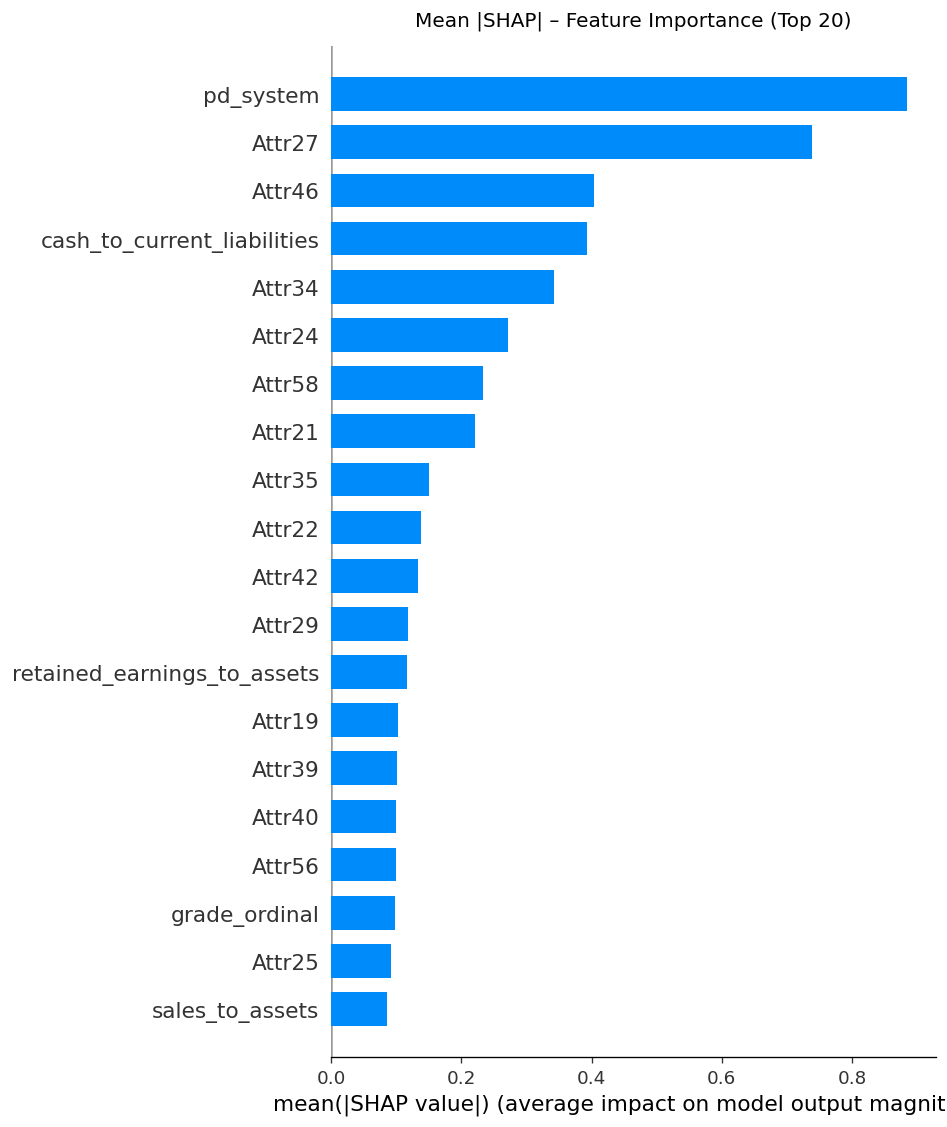

Figure saved: 13_shap_bar_importance.png
Saved: ../results/tables/10_shap_mean_absolute.csv

Top 10 features by mean |SHAP|:


,feature,mean_abs_shap,rank
0,pd_system,0.884670,1
1,Attr27,0.738910,2
2,Attr46,0.404089,3
3,cash_to_current_liabilities,0.393236,4
4,Attr34,0.342275,5
5,Attr24,0.271152,6
6,Attr58,0.233655,7
7,Attr21,0.221511,8
8,Attr35,0.150394,9
9,Attr22,0.138519,10


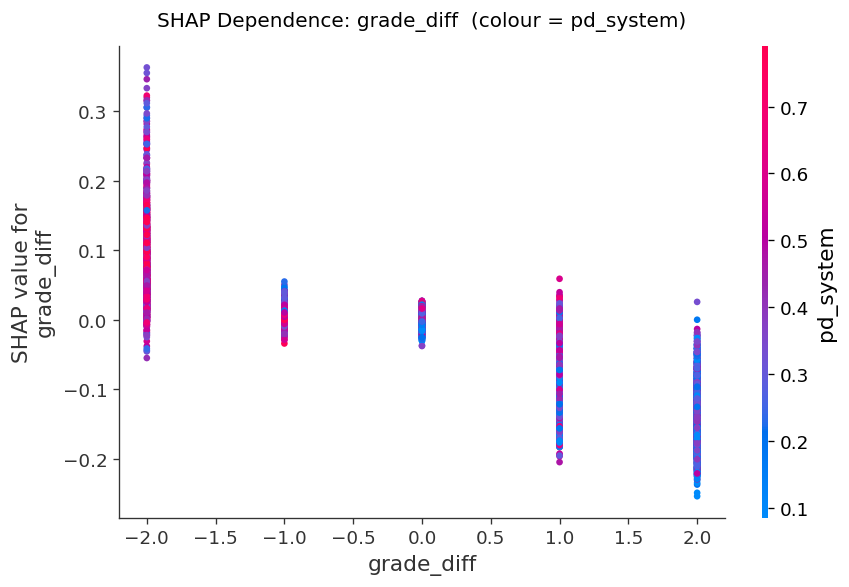

Figure saved: 14_shap_dependence_grade_diff.png
Selected case:
  System grade   : B
  Final grade    : BB
  grade_diff     : -1
  pd_system      : 0.5735
  Actual default : 1


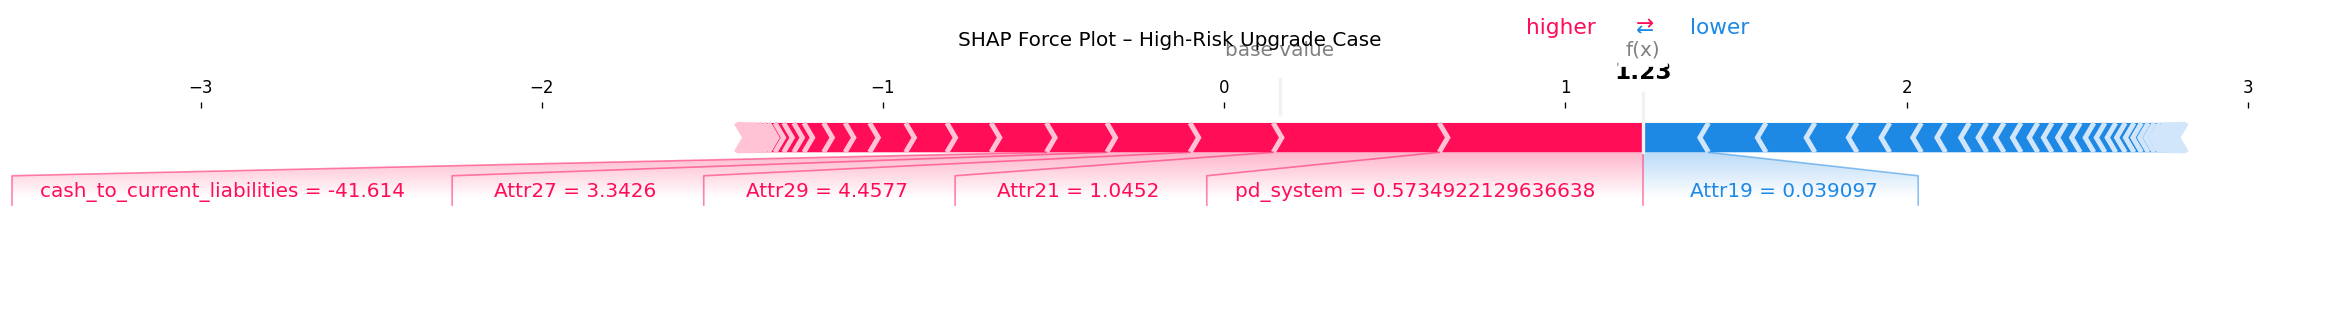

Figure saved: 15_shap_force_plot_sample.png


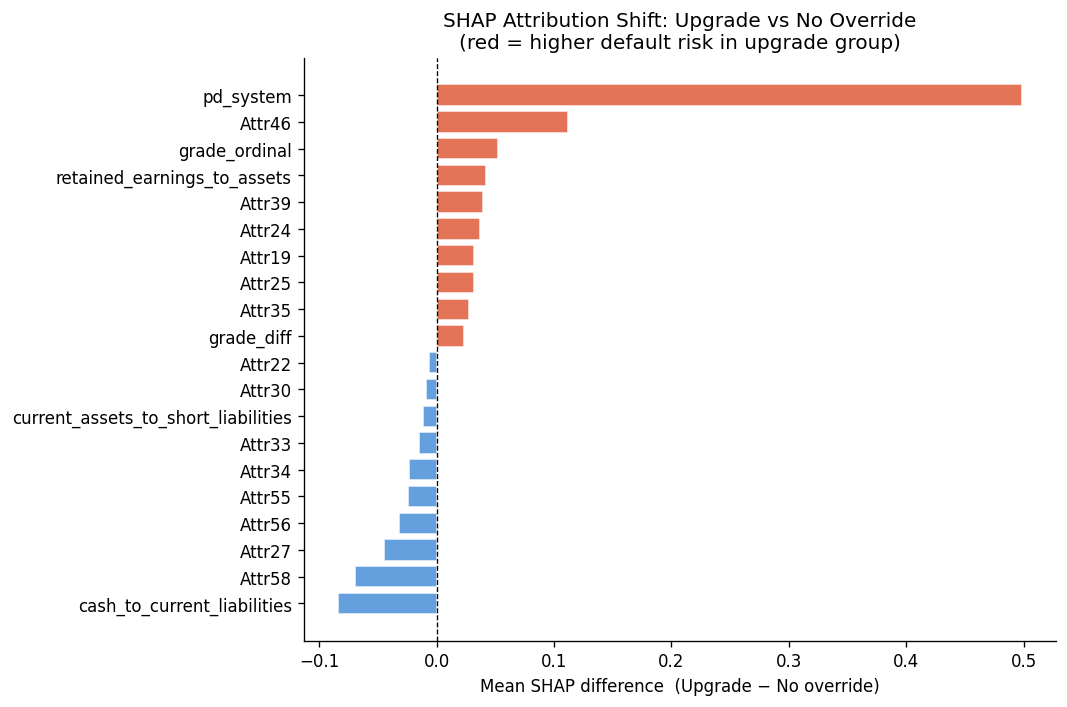

Figure saved: 16_shap_upgrade_diff.png

Override feature SHAP ranks:


,rank,mean_abs_shap
feature,,
pd_system,1,0.884670
grade_ordinal,18,0.098302
grade_diff,42,0.030627
override_flag,68,0.000499


In [4]:
# NB07_shap_explainability.ipynb

# %% [markdown]
# # NB07 – SHAP Explainability
# **Purpose:** Use SHAP (SHapley Additive exPlanations) to decompose
# XGBoost predictions and provide individual-level decision rationale
# for evaluator override cases.
#
# **Input:**
# - `data/processed/override_data.parquet`
# - `models/xgboost/xgb_override.pkl`
#
# **Output:**
# - `results/figures/12_shap_summary_beeswarm.png`
# - `results/figures/13_shap_bar_importance.png`
# - `results/figures/14_shap_dependence_grade_diff.png`
# - `results/figures/15_shap_force_plot_sample.png`
# - `results/figures/16_shap_upgrade_diff.png`
# - `results/tables/10_shap_mean_absolute.csv`

# %%
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb_lib

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
MODEL_DIR = "../models/xgboost/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

df       = pd.read_parquet(PROC_DIR + "override_data.parquet")
artifact = joblib.load(MODEL_DIR + "xgb_override.pkl")
xgb_clf      = artifact["model"]
FEATURE_COLS = artifact["feature_cols"]

X = df[FEATURE_COLS].fillna(0)
print(f"XGBoost version : {xgb_lib.__version__}")

# %% [markdown]
# ## 0. SHAP compatibility fix
# XGBoost ≥ 2.0 stores base_score as '[5E-1]'.
# SHAP's XGBTreeModelLoader reads learner_model_param from save_config()
# and calls float() on it directly — patching the booster has no effect
# because SHAP calls save_config() again internally.
#
# Fix: patch the one line in XGBTreeModelLoader.__init__ that does
#      float(learner_model_param["base_score"])
# by replacing it with a bracket-stripping version.

# %%
import shap
import shap.explainers._tree as _shap_tree

print(f"SHAP version : {shap.__version__}")

# Locate the source file and patch it at the string level
import inspect, re
src_path = inspect.getfile(_shap_tree)
print(f"Patching: {src_path}")

with open(src_path, "r", encoding="utf-8") as f:
    src = f.read()

OLD = 'self.base_score = float(learner_model_param["base_score"])'
NEW = 'self.base_score = float(str(learner_model_param["base_score"]).strip("[]"))'

if OLD in src:
    src_patched = src.replace(OLD, NEW)
    with open(src_path, "w", encoding="utf-8") as f:
        f.write(src_patched)
    print("Source patch applied. Reloading module...")

    # Force Python to reload the patched module
    import importlib
    importlib.reload(_shap_tree)
    importlib.reload(shap.explainers._tree)
    importlib.reload(shap)
    import shap  # re-import after reload
    print("Module reloaded successfully.")

elif NEW in src:
    print("Patch already applied – no change needed.")
else:
    print("WARNING: target line not found. SHAP source may have changed.")
    print("Search manually for 'base_score' in:", src_path)

# %% [markdown]
# ## 1. SHAP TreeExplainer

# %%
explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}")

# %% [markdown]
# ## 2. Global summary – beeswarm plot

# %%
shap.summary_plot(
    shap_values, X,
    plot_type   = "dot",
    max_display = 20,
    show        = False,
)
plt.title("SHAP Summary – Global Feature Impact (Top 20)", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR + "12_shap_summary_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()
print("Figure saved: 12_shap_summary_beeswarm.png")

# %% [markdown]
# ## 3. Global summary – bar plot (mean |SHAP|)

# %%
shap.summary_plot(
    shap_values, X,
    plot_type   = "bar",
    max_display = 20,
    show        = False,
)
plt.title("Mean |SHAP| – Feature Importance (Top 20)", pad=12)
plt.tight_layout()
plt.savefig(FIG_DIR + "13_shap_bar_importance.png", bbox_inches="tight", dpi=150)
plt.show()
print("Figure saved: 13_shap_bar_importance.png")

# Save mean |SHAP| table
mean_shap = pd.DataFrame({
    "feature"      : FEATURE_COLS,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

mean_shap["rank"] = mean_shap.index + 1
mean_shap.to_csv(TABLE_DIR + "10_shap_mean_absolute.csv", index=False)
print(f"Saved: {TABLE_DIR}10_shap_mean_absolute.csv")

print("\nTop 10 features by mean |SHAP|:")
display(mean_shap.head(10))

# %% [markdown]
# ## 4. SHAP dependence plot: grade_diff

# %%
if "grade_diff" in FEATURE_COLS:
    shap.dependence_plot(
        "grade_diff", shap_values, X,
        interaction_index = "pd_system",
        show              = False,
    )
    plt.title("SHAP Dependence: grade_diff  (colour = pd_system)", pad=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR + "14_shap_dependence_grade_diff.png",
                bbox_inches="tight", dpi=150)
    plt.show()
    print("Figure saved: 14_shap_dependence_grade_diff.png")
else:
    print("grade_diff not in feature set – skipping.")

# %% [markdown]
# ## 5. Individual force plot – high-risk upgrade case

# %%
upgrade_default_idx = df[
    (df["override_direction"] == "upgrade") &
    (df["default"] == 1)
].index

if len(upgrade_default_idx) > 0:
    sample_idx = upgrade_default_idx[0]
    sample_pos = X.index.get_loc(sample_idx)

    print("Selected case:")
    print(f"  System grade   : {df.loc[sample_idx, 'system_grade']}")
    print(f"  Final grade    : {df.loc[sample_idx, 'final_grade']}")
    print(f"  grade_diff     : {df.loc[sample_idx, 'grade_diff']}")
    print(f"  pd_system      : {df.loc[sample_idx, 'pd_system']:.4f}")
    print(f"  Actual default : {df.loc[sample_idx, 'default']}")

    shap.force_plot(
        explainer.expected_value,
        shap_values[sample_pos],
        X.iloc[sample_pos],
        matplotlib = True,
        show       = False,
    )
    plt.title("SHAP Force Plot – High-Risk Upgrade Case", pad=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR + "15_shap_force_plot_sample.png",
                bbox_inches="tight", dpi=150)
    plt.show()
    print("Figure saved: 15_shap_force_plot_sample.png")
else:
    print("No upgrade + default cases found.")

# %% [markdown]
# ## 6. SHAP attribution shift: upgrade vs no-override

# %%
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS, index=X.index)
shap_df["override_direction"] = df["override_direction"].values

mean_shap_by_dir = shap_df.groupby("override_direction")[FEATURE_COLS].mean()

diff_shap = (
    mean_shap_by_dir.loc["upgrade"] - mean_shap_by_dir.loc["none"]
).sort_values(ascending=False)

top10   = diff_shap.head(10)
bot10   = diff_shap.tail(10)
plot_df = pd.concat([top10, bot10]).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E05C3A" if v > 0 else "#4A90D9" for v in plot_df.values]
ax.barh(plot_df.index, plot_df.values,
        color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean SHAP difference  (Upgrade − No override)")
ax.set_title("SHAP Attribution Shift: Upgrade vs No Override\n"
             "(red = higher default risk in upgrade group)")
plt.tight_layout()
plt.savefig(FIG_DIR + "16_shap_upgrade_diff.png", bbox_inches="tight", dpi=150)
plt.show()
print("Figure saved: 16_shap_upgrade_diff.png")

# %% [markdown]
# ## 7. Override feature SHAP ranks

# %%
override_feats = ["pd_system", "grade_ordinal", "grade_diff", "override_flag"]
print("\nOverride feature SHAP ranks:")
display(
    mean_shap[mean_shap["feature"].isin(override_feats)]
    .set_index("feature")[["rank", "mean_abs_shap"]]
    .round(6)
)